# Create the Kaggle folder

In [1]:
mkdir -p ~/.kaggle

The syntax of the command is incorrect.


In [2]:
mkdir %USERPROFILE%\.kaggle

A subdirectory or file C:\Users\USER\.kaggle already exists.


In [9]:
# Install kaggle package
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ------------------------------------

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imdevskp/ebola-outbreak-20142016-complete-dataset")

print("Path to dataset files:", path)

c:\Users\USER\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 95.1k/95.1k [00:00<00:00, 402kB/s]

Extracting files...
Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\imdevskp\ebola-outbreak-20142016-complete-dataset\versions\4


In [12]:
import os 

files =  os.listdir(path)
for file in files:
    print(file)

ebola_2014_2016_clean.csv
ebola_data_db_format.csv


In [13]:
# import necessary libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [14]:
# Load both the files 
df_clean = pd.read_csv(os.path.join(path, "ebola_2014_2016_clean.csv"))
df_db = pd.read_csv(os.path.join(path, "ebola_data_db_format.csv"))

In [22]:
print("=" * 50)
print("File 1: ebola_2014_2016_clean.csv")
print("="*50)
print(f"Shape: {df_clean.shape}")


File 1: ebola_2014_2016_clean.csv
Shape: (2485, 4)


In [18]:
df_clean.head()

,Country,Date,"Cumulative no. of confirmed, probable and suspected cases","Cumulative no. of confirmed, probable and suspected deaths"
0,Guinea,2014-08-29,648.0,430.0
1,Nigeria,2014-08-29,19.0,7.0
2,Sierra Leone,2014-08-29,1026.0,422.0
3,Liberia,2014-08-29,1378.0,694.0
4,Sierra Leone,2014-09-05,1261.0,491.0


In [20]:
print("\n" + "=" * 50)
print("File 2: ebola_data_db_format.csv")
print("="* 50)
print(f"Shape: {df_db.shape}")



File 2: ebola_data_db_format.csv
Shape: (17585, 4)


In [21]:
df_db.head()

,Indicator,Country,Date,value
0,"Cumulative number of confirmed, probable and s...",Guinea,2015-03-10,3285.0
1,Cumulative number of confirmed Ebola cases,Guinea,2015-03-10,2871.0
2,Cumulative number of probable Ebola cases,Guinea,2015-03-10,392.0
3,Cumulative number of suspected Ebola cases,Guinea,2015-03-10,22.0
4,"Cumulative number of confirmed, probable and s...",Guinea,2015-03-10,2170.0


In [25]:
df_clean.columns

Index(['Country', 'Date',
       'Cumulative no. of confirmed, probable and suspected cases',
       'Cumulative no. of confirmed, probable and suspected deaths'],
      dtype='object')

In [24]:
print("FILE 1 COLUMNS:", df_clean.columns.tolist())
df_clean.head()


FILE 1 COLUMNS: ['Country', 'Date', 'Cumulative no. of confirmed, probable and suspected cases', 'Cumulative no. of confirmed, probable and suspected deaths']


,Country,Date,"Cumulative no. of confirmed, probable and suspected cases","Cumulative no. of confirmed, probable and suspected deaths"
0,Guinea,2014-08-29,648.0,430.0
1,Nigeria,2014-08-29,19.0,7.0
2,Sierra Leone,2014-08-29,1026.0,422.0
3,Liberia,2014-08-29,1378.0,694.0
4,Sierra Leone,2014-09-05,1261.0,491.0


In [26]:
df_db.columns

Index(['Indicator', 'Country', 'Date', 'value'], dtype='object')

In [29]:
# rename columns of the file 1

df_clean.columns = ['Country', 'Date', 'Cases', 'Deaths'] 
print("Shape:", df_clean.shape)
print("\n First 5 rows:")
df_clean.head()

Shape: (2485, 4)

 First 5 rows:


,Country,Date,Cases,Deaths
0,Guinea,2014-08-29,648.0,430.0
1,Nigeria,2014-08-29,19.0,7.0
2,Sierra Leone,2014-08-29,1026.0,422.0
3,Liberia,2014-08-29,1378.0,694.0
4,Sierra Leone,2014-09-05,1261.0,491.0


##  Explore the info and describe the dataset

In [31]:
# dataset info()
print("===DATASET INFO ===") 
df_clean.info()

===DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2485 entries, 0 to 2484
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  2485 non-null   object 
 1   Date     2485 non-null   object 
 2   Cases    2477 non-null   float64
 3   Deaths   2485 non-null   float64
dtypes: float64(2), object(2)
memory usage: 77.8+ KB


In [32]:
# summary statistics
print("\n== Statistical summary ===") 
df_clean.describe()


== Statistical summary ===


,Cases,Deaths
count,2477.000000,2485.000000
mean,2553.678644,1028.347686
std,4427.118148,1656.064372
min,0.000000,0.000000
25%,1.000000,0.000000
50%,8.000000,6.000000
75%,3657.000000,2386.000000
max,14122.000000,4806.000000


## Task 3: Clean: handle missing values, fix data types, remove duplicates.

In [33]:
print("\n=== Missing values ===") 
df_clean.isnull().sum()


=== Missing values ===


Country    0
Date       0
Cases      8
Deaths     0
dtype: int64

### There's no missing values from the dataset as shown from the analysis.

In [35]:
print("\n=== unique countries ===")
df_clean['Country'].unique()


=== unique countries ===


array(['Guinea', 'Nigeria', 'Sierra Leone', 'Liberia', 'Senegal',
       'United States of America', 'Spain', 'Mali', 'United Kingdom',
       'Italy'], dtype=object)

In [38]:
print("\n=== Duplicates ===")
df_clean.duplicated()


=== Duplicates ===


0       False
1       False
2       False
3       False
4       False
        ...  
2480    False
2481    False
2482    False
2483    False
2484    False
Length: 2485, dtype: bool

### There's no duplicates from the dataset as shown in the analysis.

In [41]:
# perform data cleaning

df_clean['Date'] = pd.to_datetime(df_clean['Date']) 
df_clean['Cases'] = pd.to_numeric(df_clean['Cases'], errors = 'coerce')
df_clean['Deaths'] = pd.to_numeric(df_clean['Deaths'], errors = 'coerce')

In [45]:
# Add columns 
df_clean['Month'] = df_clean['Date'].dt.to_period('M')
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Fatality_Rate'] = (df_clean['Deaths'] / df_clean['Cases'] * 100).round(2)

In [47]:
# Filter to 3 most affected countries
main_countries = ['Guinea', 'Sierra Leone', 'Liberia']
df_main = df_clean[df_clean['Country'].isin(main_countries)].copy()

In [57]:
df_clean.head()

,Country,Date,Cases,Deaths,Month,Year,Fatality_Rate
0,Guinea,2014-08-29,648.0,430.0,2014-08,2014,66.36
1,Nigeria,2014-08-29,19.0,7.0,2014-08,2014,36.84
2,Sierra Leone,2014-08-29,1026.0,422.0,2014-08,2014,41.13
3,Liberia,2014-08-29,1378.0,694.0,2014-08,2014,50.36
4,Sierra Leone,2014-09-05,1261.0,491.0,2014-09,2014,38.94


In [58]:
print("=== AFTER CLEANING ===")
print(f"Data types:\n{df_clean.dtypes}")
print(f"\nDate range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")
print(f"\nCountries: {df_main['Country'].unique()}")
print(f"\nShape: {df_main.shape}")

=== AFTER CLEANING ===
Data types:
Country                  object
Date             datetime64[ns]
Cases                   float64
Deaths                  float64
Month                 period[M]
Year                      int32
Fatality_Rate           float64
dtype: object

Date range: 2014-08-29 00:00:00 to 2016-03-23 00:00:00

Countries: ['Guinea' 'Sierra Leone' 'Liberia']

Shape: (883, 7)


### Insights: 

1. The analysis covered between August 29 2014 to March 23, 2016. 

2. Guinea, Sierra Leone and Liberia has the highest mortality rate.

In [59]:
df_main.head()


,Country,Date,Cases,Deaths,Month,Year,Fatality_Rate
0,Guinea,2014-08-29,648.0,430.0,2014-08,2014,66.36
2,Sierra Leone,2014-08-29,1026.0,422.0,2014-08,2014,41.13
3,Liberia,2014-08-29,1378.0,694.0,2014-08,2014,50.36
4,Sierra Leone,2014-09-05,1261.0,491.0,2014-09,2014,38.94
6,Liberia,2014-09-05,1871.0,1089.0,2014-09,2014,58.20


# Task 4:  Create 5 visualizations: histogram, scatter, bar chart, box plot, correlation heatmap. 

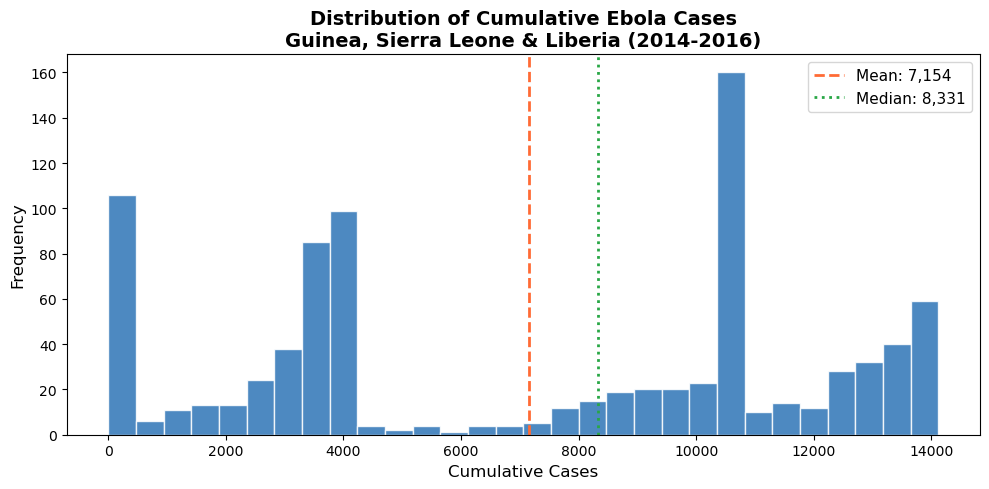

Saved: viz1_histogram.png


In [60]:
# Visualization 1 - Histogram
plt.figure(figsize=(10, 5))

plt.hist(df_main['Cases'].dropna(), bins=30,
        color='#2E75B6', edgecolor='white', alpha=0.85)

plt.axvline(df_main['Cases'].mean(), color='#FF6B35',
            linewidth=2, linestyle='--',
            label=f"Mean: {df_main['Cases'].mean():,.0f}")
plt.axvline(df_main['Cases'].median(), color='#28A745',
            linewidth=2, linestyle=':',
            label=f"Median: {df_main['Cases'].median():,.0f}")

plt.title("Distribution of Cumulative Ebola Cases\nGuinea, Sierra Leone & Liberia (2014-2016)",
        fontsize=14, fontweight='bold')
plt.xlabel("Cumulative Cases", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("viz1_histogram.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz1_histogram.png")

### What the data shows:
The distribution is bimodal — meaning there are two distinct peaks. One cluster sits around 0–500 cases and another large cluster around 3,500–4,000 cases. The mean (7,154) is significantly higher than the median (8,331) being reversed — meaning the outbreak was not uniform. Some reporting periods captured explosive surges while others showed contained spread.

### Insight:
The gap between the two clusters represents the outbreak acceleration phase — the period where containment failed and cases multiplied rapidly. This pattern is typical of an outbreak that was initially manageable but overwhelmed health infrastructure before adequate response was mounted

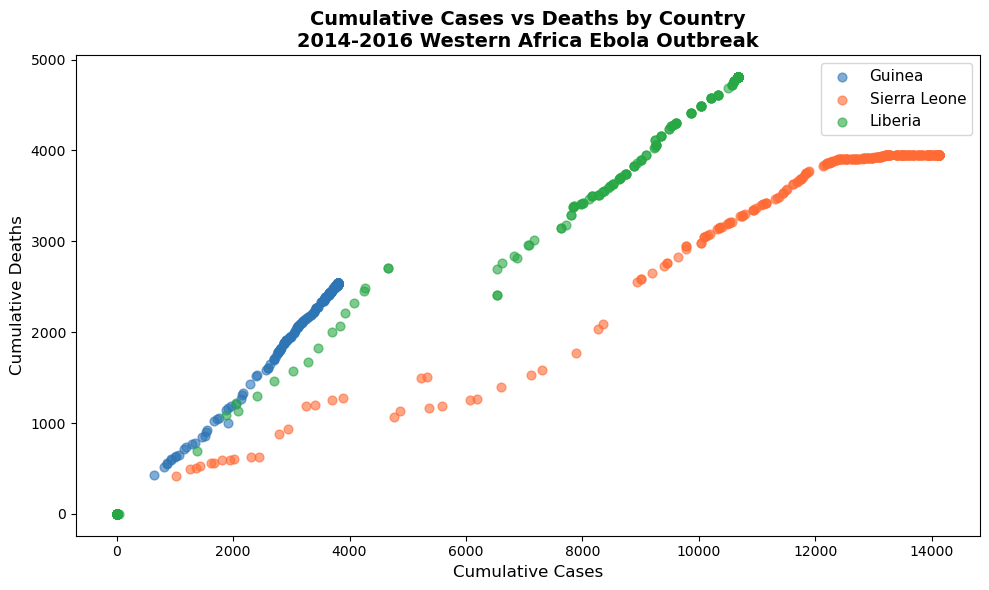

Saved: viz2_scatter.png


In [61]:
# Visualization 2 - Scatter plot
colors = {'Guinea': '#2E75B6',
          'Sierra Leone': '#FF6B35',
          'Liberia': '#28A745'}

plt.figure(figsize=(10, 6))

for country in main_countries:
    data = df_main[df_main['Country'] == country]
    plt.scatter(data['Cases'], data['Deaths'],
                label=country, alpha=0.6,
                color=colors[country], s=40)

plt.title("Cumulative Cases vs Deaths by Country\n2014-2016 Western Africa Ebola Outbreak",
          fontsize=14, fontweight='bold')
plt.xlabel("Cumulative Cases", fontsize=12)
plt.ylabel("Cumulative Deaths", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("viz2_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz2_scatter.png")


### What the data shows:
All three countries show a strong linear relationship between cases and deaths — as cases rise, deaths rise proportionally. However the slopes differ by country. Liberia shows the steepest death-to-case ratio at lower case counts, meaning early in the outbreak Liberia was losing more patients per case than the others. Sierra Leone accumulated the most cases overall (14,122) but Guinea maintained a consistently high death rate relative to its case load.

### Insight:
The differences in slope between countries reveal that healthcare capacity, not just case volume, determined survival. Countries that were overwhelmed earlier had steeper death curves even at lower case numbers.

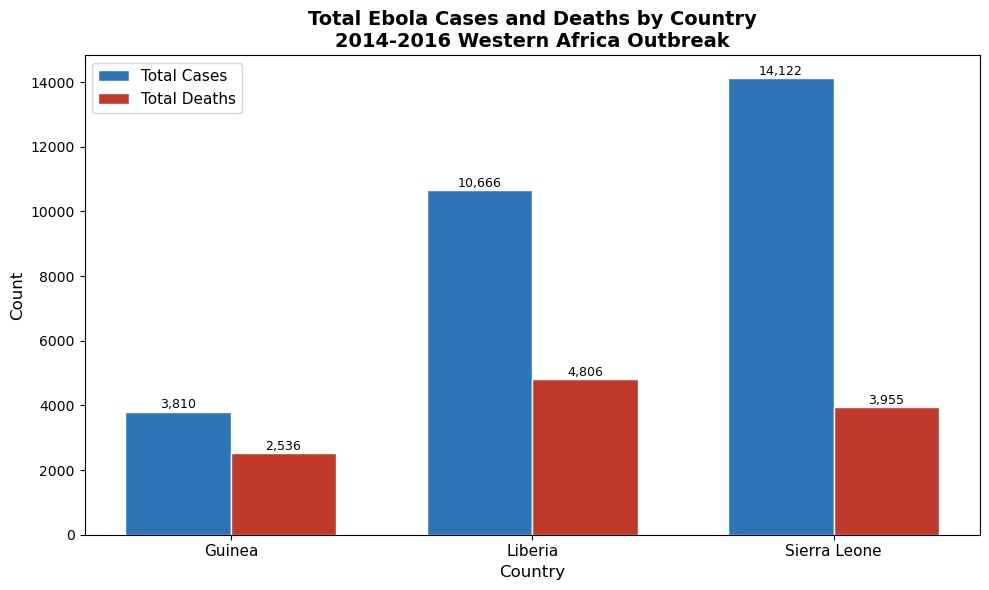

Saved: viz3_bar_chart.png


In [62]:
# Visualization 3 - Bar chart

summary = df_main.groupby('Country')[['Cases', 'Deaths']].max().reset_index()

x = range(len(summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], summary['Cases'],
               width, label='Total Cases',
               color='#2E75B6', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], summary['Deaths'],
               width, label='Total Deaths',
               color='#C0392B', edgecolor='white')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{int(bar.get_height()):,}',
            ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{int(bar.get_height()):,}',
            ha='center', fontsize=9)

ax.set_title("Total Ebola Cases and Deaths by Country\n2014-2016 Western Africa Outbreak",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Country", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(summary['Country'], fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("viz3_bar_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz3_bar_chart.png")

### What the data shows:
Sierra Leone had the highest total cases at 14,122 but Liberia had the highest deaths at 4,806 despite fewer total cases at 10,666. Guinea had the fewest cases at 3,810 but still recorded 2,536 deaths — a death-to-case ratio of approximately 66%.

### Insight:
Liberia's death toll relative to cases is the most alarming finding in this chart. More people died per infection in Liberia than Sierra Leone despite Sierra Leone having 33% more cases. This strongly suggests Liberia's healthcare system collapsed earlier and more completely — leaving patients without adequate treatment.


C:\Users\USER\AppData\Local\Temp\ipykernel_1640\1598052732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='Country', y='Cases',
C:\Users\USER\AppData\Local\Temp\ipykernel_1640\1598052732.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='Country', y='Deaths',


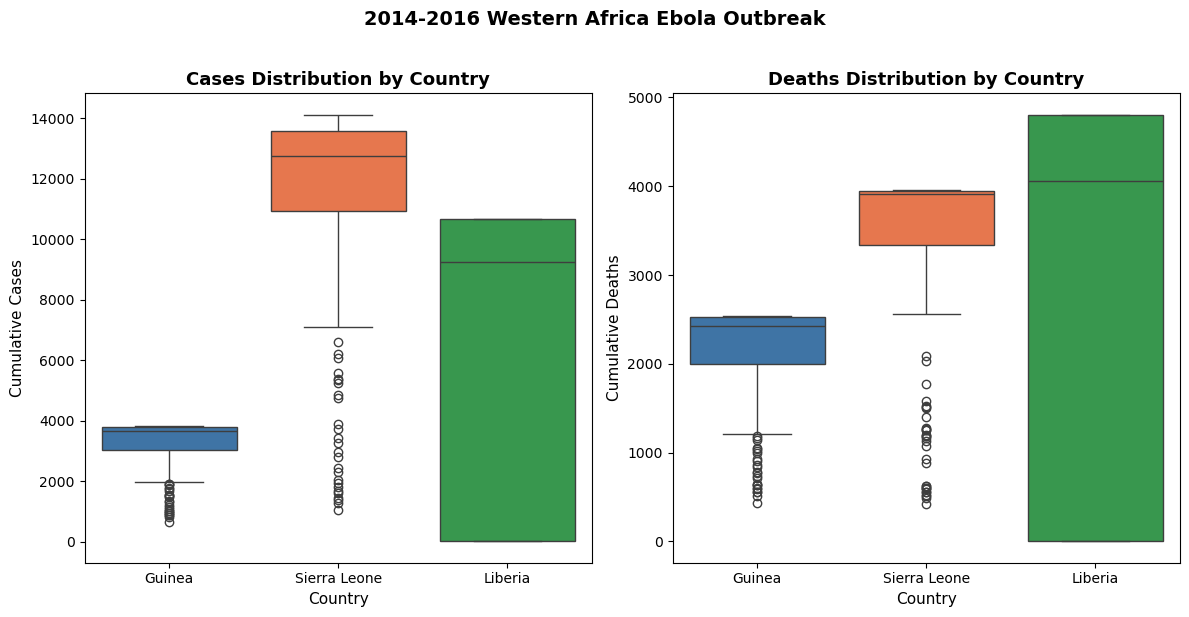

Saved: viz4_boxplot.png


In [63]:
# Visualization 4 - Box plot 

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_main, x='Country', y='Cases',
            palette=['#2E75B6', '#FF6B35', '#28A745'],
            ax=axes[0])
axes[0].set_title("Cases Distribution by Country",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("Country", fontsize=11)
axes[0].set_ylabel("Cumulative Cases", fontsize=11)

sns.boxplot(data=df_main, x='Country', y='Deaths',
            palette=['#2E75B6', '#FF6B35', '#28A745'],
            ax=axes[1])
axes[1].set_title("Deaths Distribution by Country",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel("Country", fontsize=11)
axes[1].set_ylabel("Cumulative Deaths", fontsize=11)

plt.suptitle("2014-2016 Western Africa Ebola Outbreak",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("viz4_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz4_boxplot.png")

### What the data shows:
Sierra Leone shows the widest spread with many outliers clustered at the lower end — meaning reporting was inconsistent and there were many periods of sudden surges followed by drops. Guinea shows the tightest and most consistent distribution, suggesting more stable though persistent transmission. Liberia shows a highly skewed distribution with a very wide interquartile range.

### Insight:
The outliers in Sierra Leone's data represent reporting gaps and sudden case surges — a sign of a health surveillance system that was struggling to keep accurate records during the crisis. This is a critical finding for AI and data-driven health systems — poor data quality during crises means any AI model trained on outbreak data from these regions will inherit the inconsistencies.

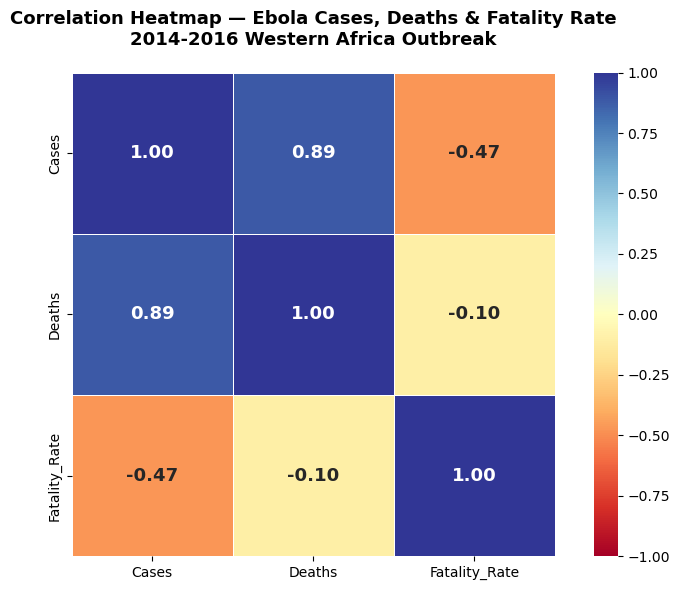

Saved: viz5_heatmap.png


In [64]:
# visualization 5 - Correlation Heatmap

corr_cols = df_main[['Cases', 'Deaths', 'Fatality_Rate']].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_cols, dtype=bool))

sns.heatmap(corr_cols, annot=True, fmt='.2f',
            cmap='RdYlBu', center=0,
            vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            annot_kws={'size': 13, 'weight': 'bold'})

plt.title("Correlation Heatmap — Ebola Cases, Deaths & Fatality Rate\n2014-2016 Western Africa Outbreak",
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("viz5_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz5_heatmap.png")

### What the data shows:
Cases and Deaths are strongly correlated at 0.89 — almost perfectly linear. Fatality Rate is negatively correlated with Cases at -0.47, meaning as cumulative cases increased over time, the fatality rate actually decreased. Fatality Rate and Deaths show only a weak negative correlation at -0.10.
### Insight:
The -0.47 correlation between Cases and Fatality Rate is the most important finding in this entire EDA. It tells you that the outbreak response improved over time — as more cases were recorded, better protocols, international support, and treatment centres were established, which brought the fatality rate down. Early in the outbreak people were dying at a far higher rate than later. This is a direct argument for early intervention systems.


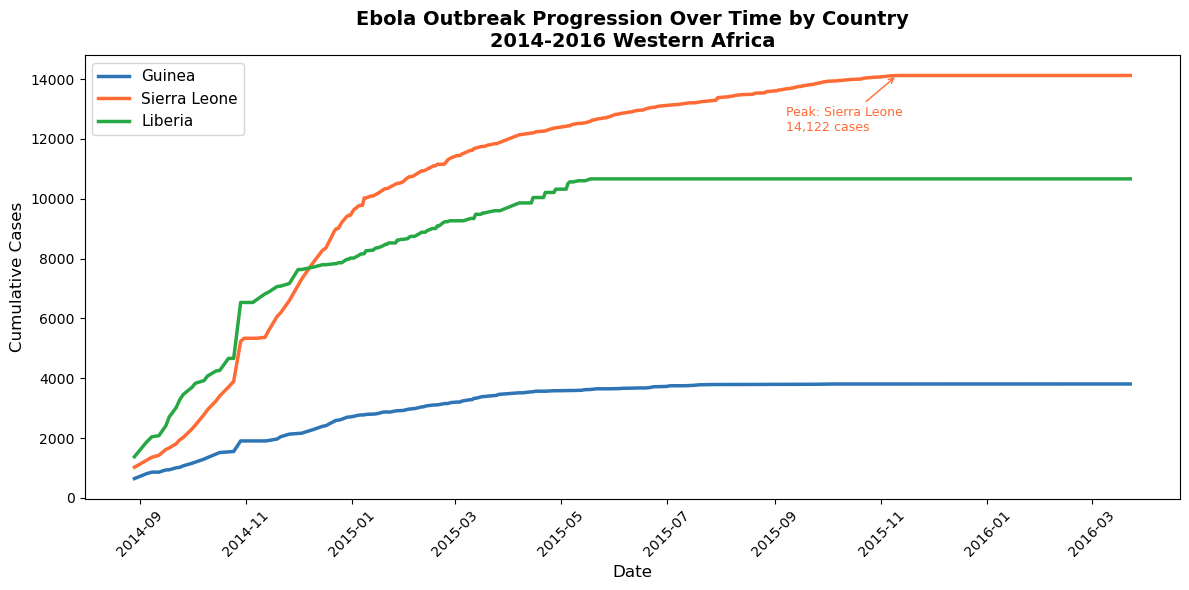

Saved: viz6_time_trend.png


In [ ]:
# visualization 6

def remove_decreasing(df_country):
    df_sorted = df_country.sort_values('Date').copy()
    df_sorted['Cases'] = df_sorted['Cases'].cummax()
    df_sorted['Deaths'] = df_sorted['Deaths'].cummax()
    return df_sorted

# Apply fix per country
df_fixed = pd.concat([
    remove_decreasing(df_main[df_main['Country'] == country])
    for country in main_countries
])

# Redraw time trend with fixed data
plt.figure(figsize=(12, 6))

for country, color in colors.items():
    data = df_fixed[df_fixed['Country'] == country]
    plt.plot(data['Date'], data['Cases'],
             label=country, color=color, linewidth=2.5)

# Add outbreak peak annotation
peak = df_fixed.loc[df_fixed['Cases'].idxmax()]
plt.annotate(f"Peak: Sierra Leone\n{int(peak['Cases']):,} cases",
             xy=(peak['Date'], peak['Cases']),
             xytext=(-80, -40), textcoords='offset points',
             fontsize=9, color='#FF6B35',
             arrowprops=dict(arrowstyle='->', color='#FF6B35'))

plt.title("Ebola Outbreak Progression Over Time by Country\n2014-2016 Western Africa",
          fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Cases", fontsize=12)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("viz6_time_trend.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz6_time_trend.png")

### The outbreak did not hit all three countries equally or at the same time.
Guinea started first and grew slowly and steadily throughout the entire outbreak. Sierra Leone started later but grew the fastest and ended up with the most cases by far — overtaking everyone else by late 2014 and never slowing down until mid-2015. Liberia had the most dramatic surge — cases jumped steeply and rapidly between September and November 2014, then flattened out completely, suggesting containment eventually worked there faster than the others.

## Five Key Insights From The Trend

-  Insight 1 — Sierra Leone was the epicentre
Sierra Leone's line rose faster and higher than any other country and took the longest to flatten. This means Sierra Leone bore the heaviest burden for the longest period. Any future outbreak response plan for West Africa must treat Sierra Leone as the highest priority country for early resource deployment.

-  Insight 2 — Liberia showed the sharpest single surge
Liberia's cases jumped from almost nothing to over 6,000 in just two months — October and November 2014. That steep vertical climb is the most dangerous pattern in outbreak data. It means the virus was spreading faster than the health system could track or respond. After that surge however, Liberia's curve flattened — meaning their containment eventually worked. That story of collapse followed by recovery is worth studying and replicating.

- Insight 3 — Guinea stayed low but never stopped
Guinea's line is the flattest and lowest but it never truly reached zero during the period shown. This is called persistent low-level transmission — small steady spread that is hard to fully eliminate. It is actually more dangerous long-term than a dramatic surge because it keeps the outbreak alive quietly while attention moves elsewhere.

- Insight 4 — The critical window was September to December 2014
All three country lines show their steepest growth during this same four-month window. This was the point where the outbreak became a regional emergency rather than isolated national incidents. A coordinated regional response during this exact window — sharing resources, closing borders strategically, and pooling health workers — could have significantly reduced the final case and death totals.

- Insight 5 — Flattening the curve is possible with intervention
Both Liberia and Sierra Leone show clear flattening by mid-2015. This did not happen by accident — it happened because international support arrived, treatment centres were built, and contact tracing improved. The data proves that intervention works. The question is always whether it arrives early enough.

## Recommendations from the analysis

- For Health Ministries: Watch your curve every week. When case numbers start climbing faster than the week before, that is your signal to act — not when hospitals are full. The time between the first steep climb and the peak is the window where lives can be saved.

- For International Organisations: The data shows the worst growth happened in a four-month window across all three countries simultaneously. Your rapid response teams and emergency supplies must be capable of deploying to multiple countries at the same time — not one at a time.

- For Regional Bodies: Guinea's persistent low-level transmission kept feeding cases into neighbouring countries. A regional outbreak is never truly over until every country in the region reaches zero. Declaring victory in one country while the virus still circulates in a neighbour is not a strategy — it is a delay.

- For AI and Data Scientists: This trend chart is exactly the kind of pattern that a well-trained early warning AI system could detect automatically — the acceleration, the surge, the plateau. Building such a system on African outbreak data, tested in African health contexts, is one of the most valuable things African AI engineers can contribute to continental health security.




